<a href="https://colab.research.google.com/github/offjisung-alt/MachineLearning/blob/main/4_%EB%B6%84%EB%A5%98%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4-1 로지스틱 회귀(Logistic Regression)

## 학습 목표

이번 장에서는 다음 내용을 학습한다.

1. KNN의 확률 예측 방법
2. 로지스틱 회귀(Logistic Regression)
3. 시그모이드 함수(Sigmoid Function)
4. 다중 분류(Multi-class Classification)
5. 소프트맥스 함수(Softmax Function)

---

# 생선 데이터 준비

입력 데이터는 다음과 같다.

- Weight (무게)
- Length (길이)
- Diagonal (대각선 길이)
- Height (높이)
- Width (너비)

정답 데이터는 다음과 같다.

- Species (생선 종류)

즉,

$$
X = [Weight,\ Length,\ Diagonal,\ Height,\ Width]
$$

$$
y = Species
$$

이다.

---

# 훈련 세트와 테스트 세트

머신러닝에서는 데이터를 두 개로 나눈다.

## 훈련 세트 (Training Set)

모델이 학습하는 데이터

## 테스트 세트 (Test Set)

학습된 모델을 평가하는 데이터

```python
train_input, test_input, train_target, test_target
```

---

# 표준화(Standardization)

각 특성의 크기가 다르기 때문에 표준화를 수행한다.

예시

```text
Weight = 1000
Width = 5
```

이 경우 Weight가 학습에 더 큰 영향을 줄 수 있다.

따라서 평균을 0, 표준편차를 1로 맞춘다.

표준화 공식

$$
z = \frac{x-\mu}{\sigma}
$$

여기서

- $\mu$ : 평균
- $\sigma$ : 표준편차

이다.

---

# K-최근접 이웃(KNN)

```python
kn = KNeighborsClassifier(n_neighbors=3)
```

KNN은 가장 가까운 데이터 K개를 보고 예측하는 알고리즘이다.

예를 들어

```text
Perch
Perch
Roach
```

가 가장 가까운 이웃이라면

```text
Perch
```

로 예측한다.

---

# KNN의 확률 예측

```python
kn.predict_proba()
```

를 사용하면 각 클래스의 확률을 확인할 수 있다.

예시

가까운 이웃 3개가

```text
Perch
Perch
Roach
```

이면

$$
P(Perch)=\frac{2}{3}=0.667
$$

$$
P(Roach)=\frac{1}{3}=0.333
$$

이 된다.

---

# KNN의 한계

KNN의 확률은

```text
0
1/3
2/3
1
```

처럼 이웃 수에 의해 결정된다.

따라서 부드러운 확률 예측이 어렵다.

이를 해결하기 위해 사용하는 모델이

**로지스틱 회귀(Logistic Regression)** 이다.

---

# 로지스틱 회귀(Logistic Regression)

이름은 회귀지만 실제로는 분류 알고리즘이다.

먼저 선형 방정식을 계산한다.

$$
z=w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$

여기서

- $x$ : 입력 데이터
- $w$ : 가중치
- $b$ : 절편

이다.

---

# 시그모이드 함수(Sigmoid Function)

선형 방정식 결과인 $z$를 확률로 바꾸기 위해 시그모이드 함수를 사용한다.

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

---

## 시그모이드 함수의 특징

출력값은 항상

$$
0 \le \sigma(z) \le 1
$$

이다.

즉,

확률처럼 해석할 수 있다.

---

## 시그모이드 함수 예시

### z가 매우 큰 경우

$$
z=10
$$

$$
\sigma(10)\approx0.99995
$$

즉,

```text
99.995%
```

의 확률이다.

---

### z가 0인 경우

$$
z=0
$$

$$
\sigma(0)=0.5
$$

---

### z가 매우 작은 경우

$$
z=-10
$$

$$
\sigma(-10)\approx0.00005
$$

즉,

거의 0%에 가깝다.

---

# 이진 분류(Binary Classification)

예를 들어

```text
도미(Bream)
빙어(Smelt)
```

두 종류만 분류한다고 가정하자.

로지스틱 회귀는

$$
P(y=1)
$$

을 계산한다.

---

## 예측 기준

### 양성 클래스

$$
P(y=1)\ge0.5
$$

이면

```text
양성 클래스
```

로 예측한다.

---

### 음성 클래스

$$
P(y=1)<0.5
$$

이면

```text
음성 클래스
```

로 예측한다.

---

# decision_function()

```python
lr.decision_function(X)
```

은 시그모이드 함수에 넣기 전의

$$
z
$$

값을 반환한다.

즉

$$
z=w_1x_1+w_2x_2+\cdots+b
$$

를 출력한다.

---

# expit()

```python
from scipy.special import expit
```

expit 함수는 시그모이드 함수이다.

즉,

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

를 계산한다.

---

# 다중 분류(Multi-Class Classification)

생선 데이터에는 총 7개의 클래스가 존재한다.

```text
Bream
Roach
Whitefish
Parkki
Perch
Pike
Smelt
```

따라서 다중 분류 문제이다.

---

# 다중 분류 로지스틱 회귀

```python
lr = LogisticRegression(C=20, max_iter=1000)
```

---

## max_iter

```python
max_iter=1000
```

학습 반복 횟수이다.

즉,

```text
1000번 반복 학습
```

을 의미한다.

---

## C

```python
C=20
```

는 규제(Regularization)의 강도를 의미한다.

주의할 점은

```text
C ↑
규제 ↓

C ↓
규제 ↑
```

이다.

---

# Softmax 함수

이진 분류에서는 시그모이드를 사용한다.

다중 분류에서는 Softmax를 사용한다.

---

## Softmax 공식

클래스 k의 확률은

$$
P(y=k)
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

이다.

---

## Softmax 특징

### 모든 확률은 0~1 사이

$$
0 \le P(y=k) \le 1
$$

---

### 확률의 합은 1

$$
\sum_{k=1}^{K}P(y=k)=1
$$

---

## Softmax 예시

점수가

```text
Bream : 1
Perch : 3
Smelt : 2
```

라고 하자.

Softmax 적용 후

```text
Bream : 0.09
Perch : 0.66
Smelt : 0.25
```

처럼 확률로 변환된다.

따라서

```text
Perch
```

로 예측한다.

---

# 전체 흐름

```text
1. 생선 데이터 불러오기

2. 훈련 세트와 테스트 세트 분리

3. StandardScaler로 표준화

4. KNN 분류 수행

5. KNN 확률 예측 확인

6. 로지스틱 회귀 학습

7. 시그모이드 함수 학습

8. 이진 분류 수행

9. 다중 분류 수행

10. Softmax로 확률 계산
```

---

# 핵심 정리

1. 로지스틱 회귀는 분류 알고리즘이다.

2. 먼저 선형 방정식

$$
z=w_1x_1+w_2x_2+\cdots+b
$$

를 계산한다.

3. 이진 분류에서는 시그모이드 함수를 사용한다.

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

4. 시그모이드 출력은 확률로 해석할 수 있다.

5. 다중 분류에서는 Softmax 함수를 사용한다.

$$
P(y=k)
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

6. Softmax의 모든 확률의 합은 1이다.

7. KNN도 확률을 계산할 수 있지만 확률 값이 제한적이다.

8. 로지스틱 회귀는 더 자연스러운 확률 예측이 가능하다.

In [ ]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [ ]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [ ]:
fish_target = fish['Species'].to_numpy()

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [ ]:
#사이킷런에서는 문자열로된 타깃값을 그대로 사용할 수 있지만, 순서가 알파벳순서가 된다.
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [ ]:
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [ ]:
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals = 4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [ ]:
distances, indexes = kn.kneighbors(test_scaled[3:4])
print(train_target[indexes])

[['Roach' 'Perch' 'Perch']]


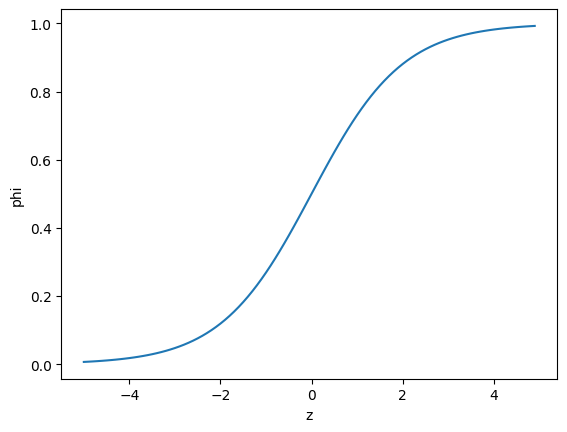

In [ ]:
#sigmoid
import numpy as np
import matplotlib.pyplot as plt
z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [ ]:
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [ ]:
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [ ]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [ ]:
print(lr.classes_)

['Bream' 'Smelt']


In [ ]:
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


In [ ]:
#z값 계산 ex. z = -0.404 x (weight)  - 0.576 x (length) ....
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [ ]:
#sigmoid 함수 적용
from scipy.special import expit
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


In [ ]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [ ]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [ ]:
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [ ]:
print(lr.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [ ]:
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


In [ ]:
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


In [ ]:
from scipy.special import softmax
proba = softmax(decision, axis = 1)
print(np.round(proba, decimals = 3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


#확률적 경사 하강법(feat. 손실함수)

# 확률적 경사 하강법 (Stochastic Gradient Descent, SGD)

## 1. 확률적 경사 하강법이란?

확률적 경사 하강법(SGD)은 손실 함수(Loss Function)를 최소화하기 위해 가중치를 조금씩 수정하며 학습하는 방법이다.

일반적인 경사 하강법은 모든 데이터를 사용하여 기울기를 계산하지만, SGD는 일부 데이터만 사용하여 기울기를 계산하고 가중치를 업데이트한다.

경사 하강법의 기본 업데이트 식은 다음과 같다.

$$
W \leftarrow W - \eta \nabla L
$$

여기서

- $W$ : 가중치(Weight)
- $\eta$ : 학습률(Learning Rate)
- $\nabla L$ : 손실 함수의 기울기(Gradient)

이다.

---

# 2. 경사 하강법 종류

## (1) 배치 경사 하강법 (Batch Gradient Descent)

전체 훈련 데이터를 사용하여 기울기를 계산한다.

### 학습 과정

```text
전체 데이터
↓
기울기 계산
↓
가중치 업데이트
↓
반복
```

### 장점

- 안정적으로 학습 가능
- 정확한 기울기 계산

### 단점

- 데이터가 많을 경우 계산량이 매우 큼
- 학습 속도가 느림

---

## (2) 확률적 경사 하강법 (SGD)

훈련 데이터 1개만 사용하여 기울기를 계산한다.

### 학습 과정

```text
데이터 1개 선택
↓
기울기 계산
↓
가중치 업데이트
↓
반복
```

### 장점

- 계산 속도가 빠름
- 대용량 데이터 학습 가능
- 메모리 사용량이 적음

### 단점

- 기울기 변화가 큼
- 학습이 불안정할 수 있음

---

## (3) 미니배치 경사 하강법 (Mini-Batch Gradient Descent)

일부 데이터만 사용하여 기울기를 계산한다.

예시

```text
32개
64개
128개
256개
```

### 학습 과정

```text
미니배치 선택
↓
기울기 계산
↓
가중치 업데이트
↓
반복
```

### 장점

- SGD보다 안정적
- 배치 경사 하강법보다 빠름
- GPU 병렬 처리 가능

현재 딥러닝에서 가장 많이 사용되는 방식이다.

---

# 생선 데이터 분류 실습

## 데이터 구성

입력 데이터(Feature)

- Weight (무게)
- Length (길이)
- Diagonal (대각선 길이)
- Height (높이)
- Width (너비)

정답 데이터(Target)

- Species (생선 종류)

즉,

$$
X=
[Weight,\ Length,\ Diagonal,\ Height,\ Width]
$$

$$
y=Species
$$

이다.

---

# 데이터 전처리

## 표준화(Standardization)

```python
ss = StandardScaler()

ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)
```

---

## 표준화를 하는 이유

각 특성의 크기가 다르기 때문이다.

예시

```text
Weight = 1000
Width = 10
```

이 경우 Weight가 학습에 훨씬 큰 영향을 줄 수 있다.

따라서 평균을 0, 표준편차를 1로 맞춘다.

표준화 공식은 다음과 같다.

$$
z=\frac{x-\mu}{\sigma}
$$

여기서

- $\mu$ : 평균
- $\sigma$ : 표준편차

이다.

표준화를 수행하면 학습 속도와 성능이 향상된다.

---

# SGDClassifier

```python
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss')
```

SGDClassifier는 확률적 경사 하강법을 이용하여 분류를 수행하는 모델이다.

---

## loss='log_loss'

```python
SGDClassifier(loss='log_loss')
```

는 로지스틱 회귀(Logistic Regression)의 손실 함수를 사용한다는 의미이다.

즉,

```text
SGDClassifier + log_loss
```

는

```text
SGD 방식으로 학습하는 로지스틱 회귀
```

라고 이해하면 된다.

---

# 모델 학습

```python
sc.fit(train_scaled, train_target)
```

`fit()`은 모델을 처음부터 학습한다.

### 학습 과정

```text
전체 훈련 데이터
↓
손실 함수 계산
↓
기울기 계산
↓
가중치 업데이트
↓
반복
```

---

# partial_fit()

```python
sc.partial_fit(train_scaled, train_target)
```

기존 모델을 유지한 상태에서 추가 학습한다.

즉,

```text
fit()
↓
partial_fit()
↓
partial_fit()
↓
partial_fit()
```

처럼 이어서 학습할 수 있다.

---

# 에포크(Epoch)

에포크(Epoch)는 전체 훈련 데이터를 한 번 모두 사용하는 것을 의미한다.

예를 들어

```text
훈련 데이터 = 1000개
```

이면

```text
1 Epoch
=
1000개 데이터를 모두 사용
```

을 의미한다.

---

# max_iter

```python
max_iter=10
```

전체 훈련 데이터를 최대 10번 반복 학습한다는 의미이다.

즉,

```text
10 Epoch
```

와 거의 같은 의미이다.

---

# 과소적합 (Underfitting)

학습이 충분하지 않은 상태

### 특징

- 훈련 정확도 낮음
- 테스트 정확도 낮음

### 원인

- Epoch 부족
- 모델이 너무 단순함

---

# 과대적합 (Overfitting)

훈련 데이터에만 지나치게 맞춘 상태

### 특징

- 훈련 정확도 높음
- 테스트 정확도 낮음

### 원인

- Epoch 과도
- 모델이 너무 복잡함

---

# 성능 확인

```python
train_score = []
test_score = []

for _ in range(300):
    sc.partial_fit(train_scaled, train_target)

    train_score.append(
        sc.score(train_scaled, train_target)
    )

    test_score.append(
        sc.score(test_scaled, test_target)
    )
```

---

## 목적

Epoch가 증가할 때

- 훈련 정확도
- 테스트 정확도

가 어떻게 변하는지 확인하기 위함이다.

이를 통해

- 과소적합
- 적절한 학습
- 과대적합

구간을 찾을 수 있다.

---

# 최종 학습

```python
sc = SGDClassifier(
    loss='log_loss',
    max_iter=100,
    tol=None,
    random_state=42
)

sc.fit(train_scaled, train_target)
```

---

## tol=None

조기 종료(Early Stopping)를 사용하지 않는다.

즉,

```text
100 Epoch까지
무조건 학습
```

한다는 의미이다.

---

# LogisticRegression과 SGDClassifier 차이

두 모델 모두 로지스틱 회귀 모델이다.

즉,

$$
P(y=1)
=
\frac{1}{1+e^{-z}}
$$

를 사용한다.

---

## LogisticRegression

```python
LogisticRegression()
```

### 특징

- LBFGS 사용
- 안정적
- 정확도 높음
- 데이터가 많으면 느림

---

## SGDClassifier

```python
SGDClassifier(loss='log_loss')
```

### 특징

- SGD 사용
- 매우 빠름
- 대용량 데이터 가능
- Online Learning 가능

---

## 차이점

LogisticRegression

```text
전체 데이터를 보고
가중치를 최적화
```

SGDClassifier

```text
일부 데이터를 보고
가중치를 조금씩 수정
```

---

# 핵심 정리

1. SGD는 일부 데이터만 사용하여 가중치를 업데이트하는 학습 방법이다.

2. SGDClassifier는 확률적 경사 하강법을 사용하는 분류 모델이다.

3. `loss='log_loss'`는 로지스틱 회귀의 손실 함수를 사용한다는 의미이다.

4. StandardScaler를 사용하여 데이터를 표준화한다.

5. 표준화 공식은

$$
z=\frac{x-\mu}{\sigma}
$$

이다.

6. `fit()`은 처음부터 학습하고 `partial_fit()`은 이어서 학습한다.

7. Epoch가 너무 적으면 과소적합이 발생한다.

8. Epoch가 너무 많으면 과대적합이 발생한다.

9. LogisticRegression과 SGDClassifier는 같은 로지스틱 회귀 모델이지만 학습 방법이 다르다.

10. 대용량 데이터에서는 SGDClassifier가 더 유리하다.

In [ ]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [ ]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=4)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [ ]:
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss = 'log_loss', max_iter = 10, random_state = 42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7563025210084033
0.875


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7647058823529411
0.975


In [ ]:
import numpy as np
sc = SGDClassifier(loss = 'log_loss', random_state = 42)
train_score = []
test_score = []
classes = np.unique(train_target)
for _ in range(0,300):
  sc.partial_fit(train_scaled, train_target, classes = classes)
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

Text(0, 0.5, 'accuracy')

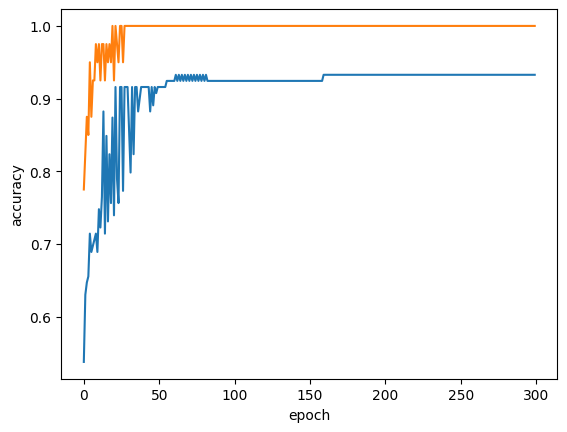

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')

In [ ]:
sc = SGDClassifier(loss = 'log_loss', max_iter = 100, tol=None, random_state = 42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9159663865546218
1.0


# Logistic Regression vs SGDClassifier

많은 사람들이

```python
from sklearn.linear_model import LogisticRegression
```

과

```python
from sklearn.linear_model import SGDClassifier

SGDClassifier(loss='log_loss')
```

를 같은 모델이라고 생각하지만, 정확히 말하면 **모델은 같고 학습 방법이 다르다.**

---

# Logistic Regression

## 기본 개념

로지스틱 회귀(Logistic Regression)는 분류 문제를 해결하기 위한 대표적인 머신러닝 알고리즘이다.

입력 데이터에 대해 선형 결합을 수행한 후 Sigmoid 함수를 적용하여 확률을 계산한다.

### 선형 결합

$$
z = w_1x_1 + w_2x_2 + \cdots + b
$$

### Sigmoid 함수

$$
P(y=1)=\frac{1}{1+e^{-z}}
$$

출력값은 항상 0과 1 사이의 확률이 된다.

---

## 예시

생선 분류 문제에서

```text
무게 = 100
길이 = 20
```

라고 가정하자.

가중치가

```text
w1 = 0.3
w2 = 0.5
b = -10
```

이면

$$
z = 0.3 \times 100 + 0.5 \times 20 - 10
$$

$$
z = 30
$$

Sigmoid를 적용하면

$$
P(y=1) \approx 0.999
$$

즉,

```text
도미일 확률 99.9%
```

라고 예측한다.

---

# LogisticRegression은 어떻게 학습할까?

Scikit-Learn의 LogisticRegression은 기본적으로

```python
solver='lbfgs'
```

를 사용한다.

대표적인 최적화 알고리즘은 다음과 같다.

- LBFGS
- Newton Method
- SAG
- SAGA

학습 과정은 다음과 같다.

```text
전체 데이터 사용
↓
손실 함수 계산
↓
기울기 계산
↓
가중치 수정
↓
반복
```

---

# SGDClassifier

```python
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss')
```

여기서

```python
loss='log_loss'
```

는 로지스틱 회귀의 손실 함수(Log Loss)를 사용한다는 의미이다.

따라서 모델 자체는 Logistic Regression과 동일하다.

즉,

$$
P(y)=sigmoid(WX+b)
$$

를 사용한다.

---

# SGDClassifier의 학습 방식

SGDClassifier는 이름 그대로

**Stochastic Gradient Descent, 확률적 경사 하강법**

으로 학습한다.

학습 과정은 다음과 같다.

```text
데이터 1개 또는 일부 데이터 선택
↓
기울기 계산
↓
가중치 수정
↓
반복
```

---

# 두 모델의 가장 큰 차이

## LogisticRegression

```text
전체 데이터를 사용하여
가중치를 수정
```

## SGDClassifier

```text
일부 데이터만 사용하여
가중치를 수정
```

---

# 비유로 이해하기

## LogisticRegression

```text
교재 전체를 읽고
정리한 후 공부

→ 정확함
→ 느림
```

## SGDClassifier

```text
한 페이지 읽고 정리
또 한 페이지 읽고 정리

→ 빠름
→ 약간 흔들릴 수 있음
```

---

# 수식으로 보는 차이

두 모델 모두 다음 식을 사용한다.

$$
\hat{y}=sigmoid(WX+b)
$$

즉, 모델 구조는 거의 동일하다.

차이는 가중치를 업데이트하는 방법이다.

---

## LogisticRegression

$$
W \leftarrow \text{LBFGS}
$$

LBFGS와 같은 최적화 알고리즘을 사용한다.

---

## SGDClassifier

$$
W \leftarrow W - \eta \nabla L
$$

경사 하강법을 사용하여 가중치를 조금씩 업데이트한다.

여기서

- $W$ : 가중치
- $\eta$ : 학습률
- $\nabla L$ : 손실 함수의 기울기

---

# partial_fit()

SGDClassifier만 제공하는 중요한 기능이다.

```python
sc.partial_fit(X, y)
```

이미 학습된 모델을 유지한 상태에서 추가 학습을 수행한다.

```text
fit()
↓
partial_fit()
↓
partial_fit()
↓
partial_fit()
```

와 같이 계속 이어서 학습할 수 있다.

---

# 장단점 비교

| 항목 | LogisticRegression | SGDClassifier |
|---|---|---|
| 모델 | 로지스틱 회귀 | 로지스틱 회귀 |
| 출력 함수 | Sigmoid | Sigmoid |
| 손실 함수 | Log Loss | Log Loss |
| 최적화 방법 | LBFGS, Newton 계열 | SGD |
| 학습 속도 | 느림 | 빠름 |
| 대용량 데이터 | 불리 | 유리 |
| Online Learning | 불가능 | 가능 |
| partial_fit | 불가능 | 가능 |
| 안정성 | 높음 | 다소 불안정 |

---

# 핵심 정리

1. LogisticRegression과 SGDClassifier(loss='log_loss')는 동일한 로지스틱 회귀 모델이다.

2. 두 모델 모두 Sigmoid 함수와 Log Loss를 사용한다.

3. 차이는 가중치를 업데이트하는 최적화 방법이다.

4. LogisticRegression은 LBFGS 같은 고급 최적화 알고리즘을 사용한다.

5. SGDClassifier는 확률적 경사 하강법(SGD)을 사용한다.

6. 데이터가 적으면 LogisticRegression이 일반적으로 더 안정적이다.

7. 데이터가 매우 많거나 실시간 학습이 필요하면 SGDClassifier가 유리하다.

---

# 한 줄 요약

**LogisticRegression과 SGDClassifier(loss='log_loss')는 같은 로지스틱 회귀 모델이지만, 가중치를 학습하는 방법이 다르다.**